In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pdf2image
from PIL import Image
import pandas as pd

In [2]:
# This is the root directory where the dataset is stored
dataset_root = '/glade/derecho/scratch/jstarfeldt/uhminicubes'

In [3]:
city = 'Atlanta'
Landsat_data = xr.open_dataset(f'{dataset_root}/hresgrid/2022/06/KATL/hresgrid_KATL_202206131612.nc')
Landsat_data

<xarray.Dataset> Size: 936MB
Dimensions:                        (y: 3000, x: 3000)
Coordinates:
  * y                              (y) float64 24kB 3.698e+06 ... 3.788e+06
  * x                              (x) float64 24kB 7.031e+05 ... 7.931e+05
    datetime                       object 8B ...
Data variables: (12/14)
    Landsat_cloud_mask             (y, x) object 72MB ...
    Landsat_blue_sfc_reflectance   (y, x) float64 72MB ...
    Landsat_green_sfc_reflectance  (y, x) float64 72MB ...
    Landsat_red_sfc_reflectance    (y, x) float64 72MB ...
    Landsat_NIR_sfc_reflectance    (y, x) float64 72MB ...
    Landsat_SWIR1_sfc_reflectance  (y, x) float64 72MB ...
    ...                             ...
    Sentinel1_VV                   (y, x) float64 72MB ...
    Sentinel1_VH                   (y, x) float64 72MB ...
    Sentinel1_HH                   (y, x) float64 72MB ...
    Sentinel1_HV                   (y, x) float64 72MB ...
    Sentinel1_incidence_angle      (y, x) float64 72MB ...
    spatial_ref                    int32 4B ...
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0
    title:          Landsat 8 and Sentinel-1 data for Atlanta, Georgia, USA
    institution:    University of Maryland, College Park
    source:         Satellite observation

In [4]:
GOES_data = xr.open_dataset(f'{dataset_root}/lresgrid/2022/06/KATL/lresgrid_KATL_202206131610.nc')
GOES_data

<xarray.Dataset> Size: 82kB
Dimensions:        (y: 45, x: 45)
Coordinates:
  * y              (y) float64 360B 3.699e+06 3.701e+06 ... 3.785e+06 3.787e+06
  * x              (x) float64 360B 7.05e+05 7.07e+05 ... 7.91e+05 7.93e+05
    datetime       object 8B ...
Data variables:
    GOES_C13_LWIR  (y, x) float64 16kB ...
    GOES_C14_LWIR  (y, x) float64 16kB ...
    GOES_C15_LWIR  (y, x) float64 16kB ...
    GOES_C16_LWIR  (y, x) float64 16kB ...
    microwave_LST  (y, x) float64 16kB ...
    spatial_ref    int32 4B ...
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0
    title:          GOES-16 and microwave LST data for Atlanta, Georgia, USA
    institution:    University of Maryland, College Park
    source:         Satellite observation

/glade/derecho/scratch/jstarfeldt/tmp/ipykernel_20323/433685416.py:17: UserWarning: The 'phony_dims' kwarg now defaults to 'access'. Previously 'phony_dims=None' would raise an error. For full netcdf equivalence please use phony_dims='sort'.
  dsMW = xr.open_dataset('/glade/derecho/scratch/jstarfeldt/uhminicubes_old/mw_data/MW_LST_DTC_20220613_x1y.h5')


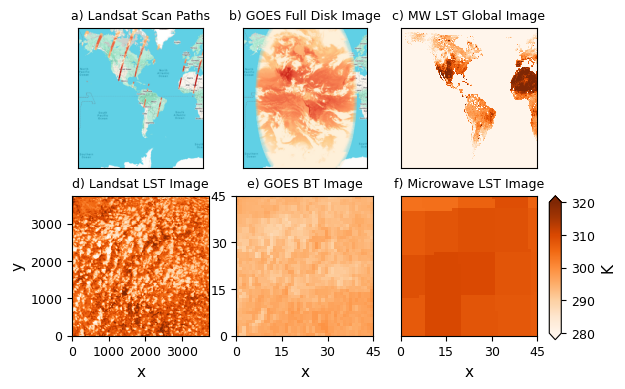

In [5]:
# Set up plot axes
fig, axs = plt.subplots(2, 3)
fig.set_size_inches(6, 4)
plt.subplots_adjust(hspace=0.2, wspace=0.2)

# Load in Landsat scan path and GOES scene images
GOES_img = pdf2image.convert_from_path('/glade/u/home/jstarfeldt/GOES_full_disk_image.pdf', use_cropbox=True)[0]
Landsat_img = pdf2image.convert_from_path('/glade/u/home/jstarfeldt/Landsat_swath_image.pdf', use_cropbox=True)[0]

#Display the images in a specific subplot
axs[0, 0].imshow(Landsat_img)
axs[0, 1].imshow(GOES_img)

# Plot Landsat LST and MW LST images
vals = Landsat_data['Landsat_LST'].values
Landsat_img = Image.fromarray(np.nan_to_num(vals, nan=np.nanmean(vals))).resize((150, 150))
dsMW = xr.open_dataset('/glade/derecho/scratch/jstarfeldt/uhminicubes_tmp/mw_data/MW_LST_DTC_20220613_x1y.h5')
dsMW = dsMW.assign_coords(
    datetime=(
        "phony_dim_0", pd.date_range(start="20221106", periods=96, freq="15min")
    ),
    longitude=(
        "phony_dim_1", np.arange(-180, 180, 0.25)
    ),
    latitude=(
        "phony_dim_2", np.arange(-60, 90, 0.25)[::-1]
    ))
mw_img = Image.fromarray(np.rot90((dsMW['TB37V_LST_DTC']/50).isel(phony_dim_0=65, phony_dim_1=range(40, 805),
                                                                  phony_dim_2=slice(63, 600)).reindex(dim=['phony_dim_2', 'phony_dim_1']))).resize((134, 191), resample=0)
axs[0, 2].pcolormesh(mw_img, cmap='Oranges', vmin=280, vmax=320)
cb = axs[1, 0].pcolormesh(np.array(Landsat_img), cmap='Oranges', vmin=280, vmax=320)
axs[1, 1].pcolormesh(GOES_data['GOES_C14_LWIR'], cmap='Oranges', vmin=280, vmax=320)
axs[1, 2].pcolormesh(GOES_data['microwave_LST'], cmap='Oranges', vmin=280, vmax=320)

# Set axis labels
axs[0, 0].set_xticks([])
axs[0, 0].set_yticks([])
axs[0, 1].set_xticks([])
axs[0, 1].set_yticks([])
axs[0, 2].set_xticks([])
axs[0, 2].set_yticks([])
axs[1, 0].set_xticks([0, 40, 80, 120])
axs[1, 0].set_yticks([0, 40, 80, 120])
axs[1, 0].set_xticklabels([0, 1000, 2000, 3000])
axs[1, 0].set_yticklabels([0, 1000, 2000, 3000])
axs[1, 0].tick_params(axis='both', labelsize=9)
axs[1, 1].set_xticks([0, 15, 30, 45])
axs[1, 1].set_yticks([0, 15, 30, 45])
axs[1, 1].tick_params(axis='both', labelsize=9)
axs[1, 2].set_yticks([])
axs[1, 2].set_xticks([0, 15, 30, 45])
axs[1, 2].tick_params(axis='both', labelsize=9)
axs[1, 0].set_xlabel('x', fontsize=11)
axs[1, 0].set_ylabel('y', fontsize=11)
axs[0, 2].set_xlabel('')
axs[0, 2].set_ylabel('')
axs[1, 1].set_xlabel('x', fontsize=11)
axs[1, 2].set_xlabel('x', fontsize=11)

# Add subplot titles
axs[0, 0].set_title('a) Landsat Scan Paths', fontsize=9)
axs[0, 1].set_title('b) GOES Full Disk Image', fontsize=9)
axs[0, 2].set_title('c) MW LST Global Image', fontsize=9)
axs[1, 0].set_title('d) Landsat LST Image', fontsize=9)
axs[1, 1].set_title('e) GOES BT Image', fontsize=9)
axs[1, 2].set_title('f) Microwave LST Image', fontsize=9)

# Add a colorbar for the LST images
cbar_ax = fig.add_axes([0.92, 0.1, 0.02, 0.36])
cbar = fig.colorbar(cb, cax=cbar_ax, label='K', extend='both')
cbar.set_label(label='K', size=11)
cbar.ax.tick_params(labelsize=9)

# Save the figure
fig.savefig('/glade/derecho/scratch/jstarfeldt/data_analysis/plots/Satellite_reference.svg', transparent=True, bbox_inches='tight')